In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import glob
from scipy.interpolate import interp1d

In [2]:
from RaTag.core.config import XRayConfig, FitConfig

from RaTag.io.file_ops import iter_waveforms, load_wfm, load_waveform_by_uid
from RaTag.plotting import plot_waveform
from RaTag.core.paths import get_output_root
from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.el_tpc.drift_workflow import map_drift_physics
from RaTag.thgem_tpc.timing_workflow import map_time_windows, resolve_set_timing, map_timing_plots
from RaTag.thgem_tpc.xray_workflow import (map_xray_events, resolve_set_xrays)
from RaTag.waveform.preprocessing import standard_preprocessing
from RaTag.io.file_ops import iter_waveforms, load_wfm, load_yaml

In [7]:
config_path = '/Users/pabloherrero/sabat/RaTagging/configs/xrays/run47_xrays.yaml'

run = bootstrap_from_config(config_path)
# run = map_drift_physics(run, force=False)

Found 1 directories in RUN47_xrays
  → Bootstrapped 1 PMT Sets and 0 Alpha Sets. (Multi-Isotope: False)


In [4]:
config = load_yaml(config_path)
xray_config_dict = config['xray_classification']
xray_config = XRayConfig(**xray_config_dict)

# Timing Workflow

In [13]:
run = map_time_windows(run, max_frames=1200, force=True)

/Users/pabloherrero/sabat/RaTagging/RaTag/thgem_tpc/timing_workflow.py:66: RuntimeWarning: Mean of empty slice
  mean_init = np.nanmean(times_arr)
/Users/pabloherrero/sabat/RaTagging/.venv/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  ✓ FieldScan_Gate0120_Anode1120: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0188_Anode1188: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0288_Anode1288: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0480_Anode1480: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0576_Anode1576: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0672_Anode1672: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0768_Anode1768: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0864_Anode1864: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0960_Anode1960: Computed 't_s2_end' and stored metadata


In [16]:
run = map_timing_plots(run, force=True)


GENERATING TIMING PLOTS: RUN_43
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/timing/FieldScan_Gate0120_Anode1120_timing.npz
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/timing/FieldScan_Gate0188_Anode1188_timing.npz
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/timing/FieldScan_Gate0288_Anode1288_timing.npz
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/timing/FieldScan_Gate0480_Anode1480_timing.npz
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/timing/FieldScan_Gate0576_Anode1576_timing.npz
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/timing/FieldScan_Gate0672_Anode1672_timing.npz
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/timing/FieldScan_Gate0768_Anode1768_timing.npz
  Loading timing arrays from: /Volumes/KINGSTON/Ra

# Plot individual waveforms

In [7]:
set0 = run.sets[0]
file_idx = 0
wfm = load_wfm(set0.source_dir / set0.filenames[file_idx])
frame_idx = 0

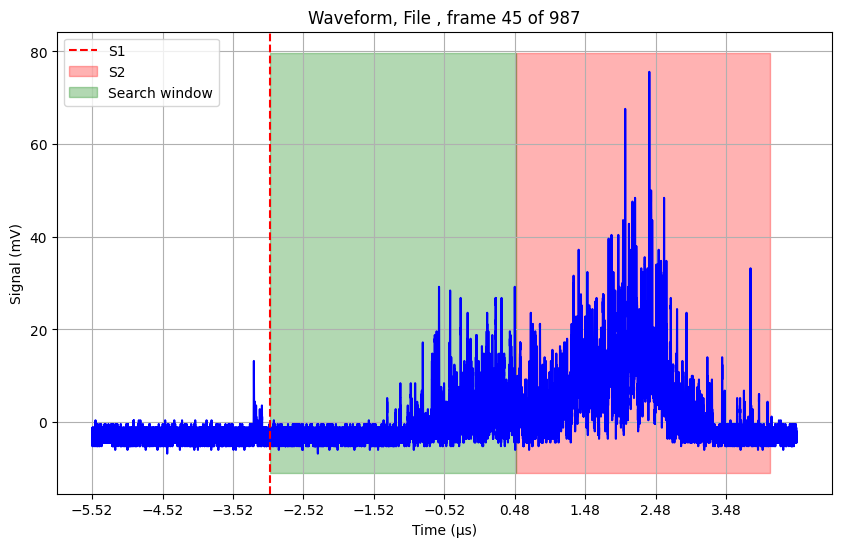

In [10]:
frame_idx += 1
# frame_idx = 6 # Good example of x-ray event (file_idx = 20)
frame_idx = 45 # Good example of possible x-ray event (file_idx = 0)

ax, _ = plot_waveform(wfm, frame=frame_idx)
ylims = ax.get_ylim()
plt.axvline(x=-3.0, color='r', linestyle='--', label='S1')
plt.fill_between(x=[0.5, 4.1], y1=ylims[0], y2=ylims[1], color='r', alpha=0.3, label='S2')
plt.fill_between(x=[-3.0, 0.5], y1=ylims[0], y2=ylims[1], color='g', alpha=0.3, label='Search window')

plt.legend()

In [193]:
areas_array, uids, stats = calculate_xray_areas(set0, max_files = 1, config=xray_config)

  Searching X-Ray window: [-3.00, 0.50] µs
  Iterating FieldScan_Gate0060_Anode1060: 1/1 (100.0%) | ETA: 00:00   
    ✓ Classified 987 frames: 322 accepted
      - Clipping reject:  14
      - SPE/Grass reject: 651


# X-ray search:

We set the search window [t_s1, t_s2_start] manually on the set attributes

In [14]:
set0 = run.sets[0]
set0.t_s1 = -3.0
set0.t_s2_start = 0.5

In [7]:
set0x = resolve_set_xrays(set0, max_frames=None, config=xray_config, force=True)

  Mapping 99 files in geometric partition [-3.0 - 0.5 | 0.5 - [END] µs
    -> Processing batch 0 to 50...
    ✓ Batch: 18308/49350 xray | 25049/49350 recoil | Rejects: 1774 clip, 22769 EL min V, 29552 Drift min V    -> Processing batch 50 to 99...
    ✓ Batch: 18040/48363 xray | 24516/48363 recoil | Rejects: 1680 clip, 22352 EL min V, 28943 Drift min V
  ✓ Set FieldScan_Gate0060_Anode1060 Audit: 36348 X-Rays | 49565 Recoils / 97713 total


In [7]:
run = map_xray_events(run, max_frames = xray_config.max_frames, config=xray_config)


IDENTIFYING X-RAY EVENTS: RUN_47
  Loading xray_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN47_xrays/xray_areas/FieldScan_Gate0060_Anode1060_xray_areas.npz
  📂 FieldScan_Gate0060_Anode1060: Loaded 'xray_areas' arrays from disk
  Aggregating run-level X-ray areas...
  Loading xray_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN47_xrays/xray_areas/FieldScan_Gate0060_Anode1060_xray_areas.npz
      Loaded 2432433 X-ray events from set FieldScan_Gate0060_Anode1060


In [9]:
path_xrays = '/Volumes/KINGSTON/RaTag_data/processed/RUN47_xrays/xray_areas/FieldScan_Gate0288_Anode1288_xray_areas.npz'
xrays_file = np.load(path_xrays, allow_pickle=True)
xrays_areas = xrays_file['s2_areas']
xrays_uids = xrays_file['uids']
xrays_file['stats']

array(['{"total": 3947013, "pass_clip": 3704851, "pass_v_min_el": 2824277, "pass_v_min_drift": 968476, "accepted_xray": 842716, "accepted_recoil": 2597090}'],
      dtype='<U147')

In [12]:
import json

In [13]:
stats_str = xrays_file['stats'].item()
stats_dict = json.loads(stats_str)
stats_dict['accepted_xray'] / stats_dict['total'], stats_dict['accepted_xray'] / stats_dict['accepted_recoil']


(0.21350727752860202, 0.32448471173505733)

In [10]:
path_recoils = '/Volumes/KINGSTON/RaTag_data/processed/RUN47_xrays/s2_areas/FieldScan_Gate0288_Anode1288_s2_areas.npz'
recoils_file = np.load(path_recoils, allow_pickle=True)
recoils_areas = recoils_file['s2_areas']
recoils_uids = recoils_file['uids']

In [12]:
len(xrays_areas), len(recoils_areas)

(2432433, 3301702)

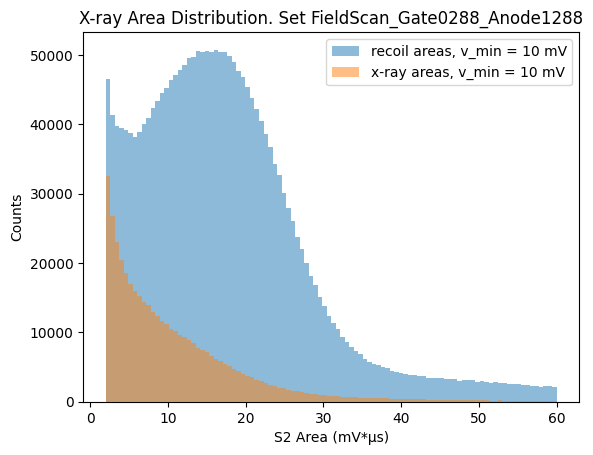

In [17]:
plt.hist(recoils_areas, bins=100, range=(2., 60), alpha=0.5, label='recoil areas, v_min = 10 mV');
plt.hist(xrays_areas, bins=100, range=(2., 60), alpha=0.5, label='x-ray areas, v_min = 10 mV', zorder=10);
plt.gca().set(xlabel='S2 Area (mV*µs)', ylabel='Counts', title=f'X-ray Area Distribution. Set FieldScan_Gate0288_Anode1288')
plt.legend()

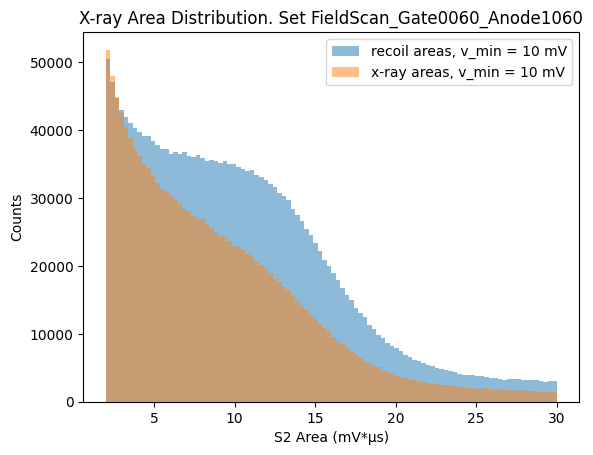

In [ ]:
plt.hist(recoils_areas, bins=100, range=(2., 30), alpha=0.5, label='recoil areas, v_min = 10 mV');
plt.hist(xrays_areas, bins=100, range=(2., 30), alpha=0.5, label='x-ray areas, v_min = 10 mV', zorder=10);
plt.gca().set(xlabel='S2 Area (mV*µs)', ylabel='Counts', title=f'X-ray Area Distribution. Set {set0.name}')
plt.legend()

In [188]:
x_idx = 0

In [179]:
xrays_uids[x_idx], xrays_areas[x_idx]
xrays_areas

array([ 9.77869829,  1.25078009, 38.69582754, ...,  3.50840745,
       11.46251841,  8.09264857])

In [203]:
uids[:8]

array([128, 132, 133, 162, 173, 184, 197, 207])

In [1]:
win_mask = _get_window_mask(wf.t, set0.t_s1, set0.t_s2_start)

x_idx += 1
# wf, frame_idx = load_waveform_by_uid(set0x, xrays_uids[x_idx])
wf, frame_idx = load_waveform_by_uid(set0x, uids[x_idx])

plot_waveform(wf, frame_idx, title=f'X-ray Event {uids[x_idx]}')
ylims = ax.get_ylim()
plt.axvline(x=-3.0, color='r', linestyle='--', label='S1')
plt.fill_between(x=[0.5, 4.1], y1=ylims[0], y2=ylims[1], color='r', alpha=0.3, label='S2')
plt.fill_between(x=[-3.0, 0.5], y1=ylims[0], y2=ylims[1], color='g', alpha=0.3, label='Search window')
wf_proc = standard_preprocessing(wf, n_pedestal=int(xray_config.n_pedestal),
                                    ma_window=int(xray_config.ma_window),
                                    threshold=float(xray_config.bs_threshold))
v_2d = wf_proc.v
v_win = v_2d[frame_idx, win_mask]
areas = np.trapezoid(v_win, dx=xray_config.dt)
plt.plot(wf.t[win_mask], v_win, color='orange', label='Area = {:.2f} mV*µs'.format(areas))
print(areas_array[x_idx])
plt.legend()

NameError: name '_get_window_mask' is not defined

In [160]:
xray_config

XRayConfig(force=False, max_frames=None, bs_threshold=0.5, max_area_s1='1.0e5', max_area_s2='1.0e5', min_xray_area=0.5, min_s2_sep=1.0, min_s1_sep=0.5, n_pedestal=200, ma_window=10, dt=0.0002, max_v_clip=150)